# **The Antarctic Baseline: Quantifying Environmental Dynamics in Near Zero-Radiance Regimes**
## *Part 2: Ensemble Learning and Explainable Machine Learning for Antarctic Surface Albedo Prediction*
---

## *Recap from Part 1*

Part 1 of this study established a statistical baseline for modeling Antarctic surface albedo over the Larsen C Ice Shelf using a custom Degree-2 Polynomial Regression model optimized through Gradient Descent. Using ten years of satellite-derived environmental observations (2015-2025), the analysis demonstrated that a lightweight regression framework could successfully capture the dominant reflectance behavior of the ice shelf.

However, residual diagnostics revealed that model performance declined under rare low-albedo conditions. While the polynomial model represented average environmental behavior effectively, it struggled to capture abrupt reflectance reductions associated with less common surface states. These findings suggest that a single global regression surface may not be flexible enough to describe the full range of environmental variability present within the Antarctic system.

Part 2 builds directly on this foundation by introducing ensemble-based machine learning approaches that can learn localized non-linear relationships without assuming a single global functional form.

---

## **Problem Statement**

>This notebook investigates whether tree-based ensemble learning methods can improve the prediction of Antarctic surface albedo compared to the polynomial baseline developed in Part 1. By evaluating Decision Trees, Random Forests, AdaBoost, and explainable machine learning techniques, the study examines whether localized non-linear models can better represent complex reflectance behavior across the Larsen C Ice Shelf.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
df=pd.read_csv("C:/Users/User/Downloads/larsen_c_cleaned_data.csv")
df.head()

,date,surface_temp,solar_zenith,surface_albedo
0,2015-01-01,-4.490099,53.772216,0.733728
1,2015-01-02,-3.446475,54.129804,0.732435
2,2015-01-03,-3.397931,51.971582,0.731124
3,2015-01-04,-5.659448,57.299931,0.733065
4,2015-01-05,-19.234894,56.139842,0.732165


The dataset used in this notebook was generated during Part 1 of the study and contains satellite-derived environmental observations extracted over the Larsen C Ice Shelf. The cleaned dataset includes surface temperature, solar zenith angle, and surface albedo measurements that were prepared for machine learning analysis. 

In [2]:
df.describe()

,surface_temp,solar_zenith,surface_albedo
count,2700.000000,2700.000000,2700.000000
mean,-21.290619,68.316284,0.708251
std,9.915108,10.094106,0.049326
min,-59.593810,51.186503,0.380821
25%,-28.326302,59.044074,0.675104
50%,-20.284837,67.165502,0.719075
75%,-13.500388,78.136491,0.745669
max,0.091557,94.162618,0.808750


Surface temperature and solar zenith angle are used as predictor variables, while surface albedo serves as the target variable to be estimated by the ensemble learning models.

In [3]:
X=df[['surface_temp', 'solar_zenith']]
y=df['surface_albedo']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=726)

Part 1 demonstrated that a single polynomial equation could capture the overall relationship between environmental variables and surface albedo, but it struggled under uncommon low-albedo conditions.

Tree-based models were selected because they can learn non-linear environmental thresholds directly from the data. Unlike polynomial regression, they do not assume a single mathematical relationship across all observations.

Three complementary approaches were used:

- Decision Tree to identify localized environmental decision rules.
- Random Forest to test whether averaging multiple trees improves predictive stability.
- AdaBoost to examine whether sequentially focusing on difficult observations improves performance.

Together, these models provide a progression from a single interpretable tree to more advanced ensemble-learning techniques while remaining accessible and easy to interpret.

---

## *Decision Tree Regression*

In Part 1, a single polynomial equation was used to describe the relationship between environmental variables and surface albedo. While this approach successfully captured the dominant reflectance behavior across the Larsen C Ice Shelf, the diagnostic analyses showed that it struggled to reproduce rare low-albedo events and tended to smooth extreme observations toward the overall dataset mean.


A Decision Tree takes a different approach. Instead of fitting one global equation, it repeatedly divides the dataset into smaller groups based on feature values and learns local prediction rules within each region. This allows the model to capture non-linear relationships and sudden changes that may be difficult to represent using a single regression.

For Antarctic surface conditions, this flexibility may help improve predictions during unusual reflectance events where albedo departs from its dominant ice-covered state.


In [4]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
tree=DecisionTreeRegressor(max_depth=4,random_state=726)
tree.fit(X_train, y_train)
pred_tree=tree.predict(X_test)
mse_tree=mean_squared_error(y_test, pred_tree)
r2_tree=r2_score(y_test, pred_tree)
print("Decision Tree MSE :", mse_tree)
print("Decision Tree R^2  :", r2_tree)

Decision Tree MSE : 0.0008241524737932535
Decision Tree R^2  : 0.658254325180921


## *Interpretation*

The Decision Tree achieved an approximate Mean Squared Error (MSE) of *0.0008241524737932535* and an $R^2$ score of *0.658254325180921* on the test dataset.

- Compared to the polynomial regression baseline from Part 1, the Decision Tree produced a slightly lower prediction error. Although the improvement in MSE is modest, the tree introduces a fundamentally different learning strategy by dividing the data into localized decision regions rather than fitting a single global equation. This allows the model to better represent non-linear environmental behavior.
- An $R^2$ value of approximately 0.66 indicates that the model explains about 66% of the observed variation in surface albedo using only surface temperature and solar zenith angle. This suggests that a substantial portion of Antarctic reflectance variability can be captured using a small set of environmental predictors.

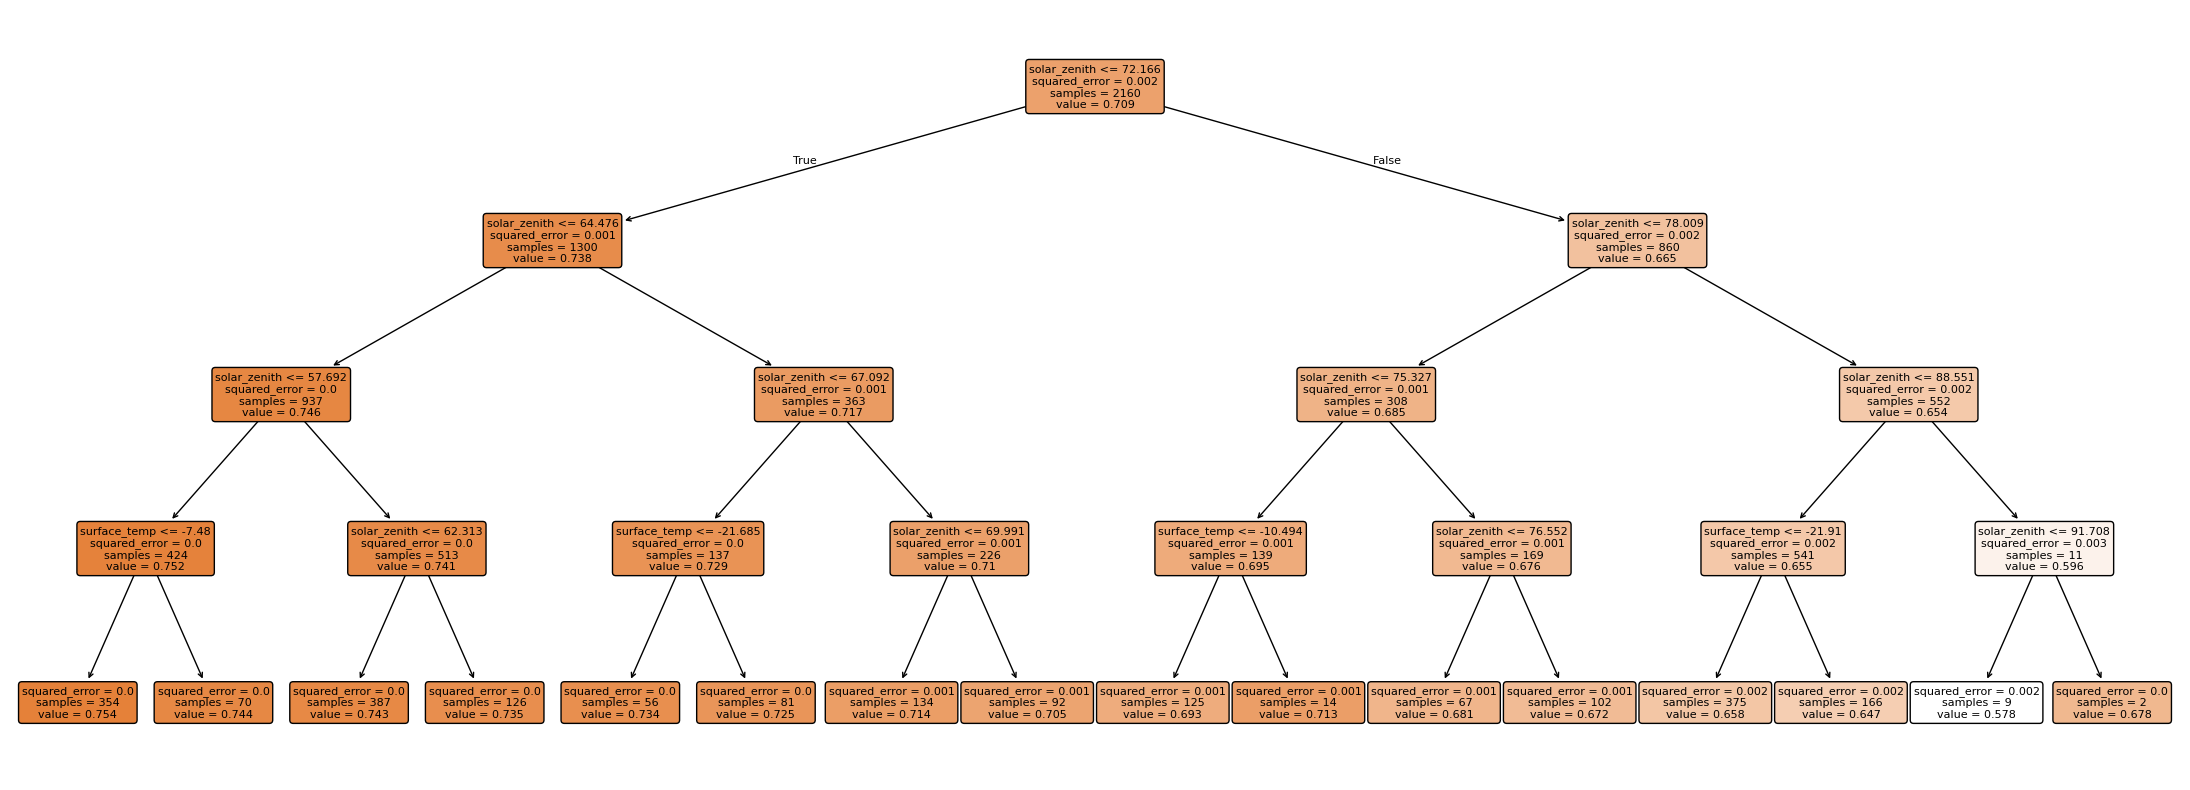

In [5]:
from sklearn.tree import plot_tree
plt.figure(figsize=(28,10))
plot_tree(tree,feature_names=['surface_temp', 'solar_zenith'],filled=True,rounded=True,fontsize=8)
plt.show()

## Interpretation of the Decision Tree

The structure of the Decision Tree provides insight into how the model organizes environmental conditions before making albedo predictions.

1) *Solar Zenith*

The first split of the tree occurs on solar zenith angle, and the upper levels continue to rely heavily on this variable. This suggests that large-scale differences in Antarctic surface albedo are primarily associated with changes in solar illumination geometry rather than temperature alone.

In practical terms, the amount and angle of incoming sunlight appear to explain most of the broad reflectance patterns observed across the Larsen C Ice Shelf. The tree therefore uses solar zenith angle to create the major environmental groups before considering any additional factors.

2) *Temperature*

Temperature first appears deeper in the tree, where it is used to refine predictions within already-defined solar conditions. This does not mean temperature is of lesser importance. Instead, it suggests that temperature acts as a more localized influence on albedo after the broader illumination regime has been established.

The model therefore treats solar geometry as the primary source of variation and temperature as a secondary factor that helps explain smaller differences within those groups.

### Capturing Extreme Albedo Conditions

One of the main limitations of the Polynomial Regression model in Part 1 was its tendency to smooth predictions toward the average behavior of the dataset. As a result, very low-albedo observations were often predicted as higher values.

The Decision Tree overcomes this limitation. Instead of forcing all observations to follow a rigid mathematical rule, the tree can isolate rare environmental conditions and assign them their own prediction region.

The branch leading to the low-albedo leaf value of *0.578* demonstrates this behavior. By repeatedly applying solar zenith thresholds, the model successfully separates a small group of extreme observations from the rest of the dataset. This shows how tree-based methods can capture unusual environmental states that are difficult to represent using a single global regression equation.

Overall, the Decision Tree provides early evidence that localized non-linear models are better suited for representing complex Antarctic albedo behavior than a single polynomial relationship.

---

## *Random Forest Regression*

A Decision Tree learns a single set of splitting rules from the training data. While it can capture non-linear relationships, its predictions may depend heavily on the specific samples used during training.
Random Forest addresses this limitation by building many Decision Trees on different subsets of the data and combining their predictions. Instead of relying on one tree, the final prediction is obtained by averaging the outputs of multiple trees.
This approach typically reduces prediction variance, improves generalization, and produces more stable results when environmental conditions vary across the dataset.


In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
rf=RandomForestRegressor(n_estimators=100,max_depth=4,random_state=726)
rf.fit(X_train, y_train)
pred_rf=rf.predict(X_test)
mse_rf=mean_squared_error(y_test,pred_rf)
r2_rf=r2_score(y_test, pred_rf)
print("Random Forest MSE :", mse_rf)
print("Random Forest R^2  :", r2_rf)

Random Forest MSE : 0.000793091487981667
Random Forest R^2  : 0.6711341719256259


## *Interpretation*

The Random Forest model achieved a Mean Squared Error (MSE) of *0.000793* and an $R^2$ score of *0.671134* on the test dataset.

Among all models evaluated in this study, Random Forest produced the strongest predictive performance. The lower MSE and higher $R^2$ indicate that combining the predictions of multiple decision trees improved the model's ability to capture non-linear relationships between environmental conditions and surface albedo.

An $R^2$ value of approximately *0.671134* indicates that the model explains around 67% of the observed variation in Antarctic surface albedo using only surface temperature and solar zenith angle. This represents a modest improvement over the baseline Decision Tree and suggests that ensemble averaging helped improve generalization to unseen observations.

Unlike a single Decision Tree, which relies on one set of environmental decision rules, Random Forest aggregates predictions from many trees trained on different subsets of the data. This approach reduces sensitivity to individual splits and can produce more stable predictions across a wider range of environmental conditions.


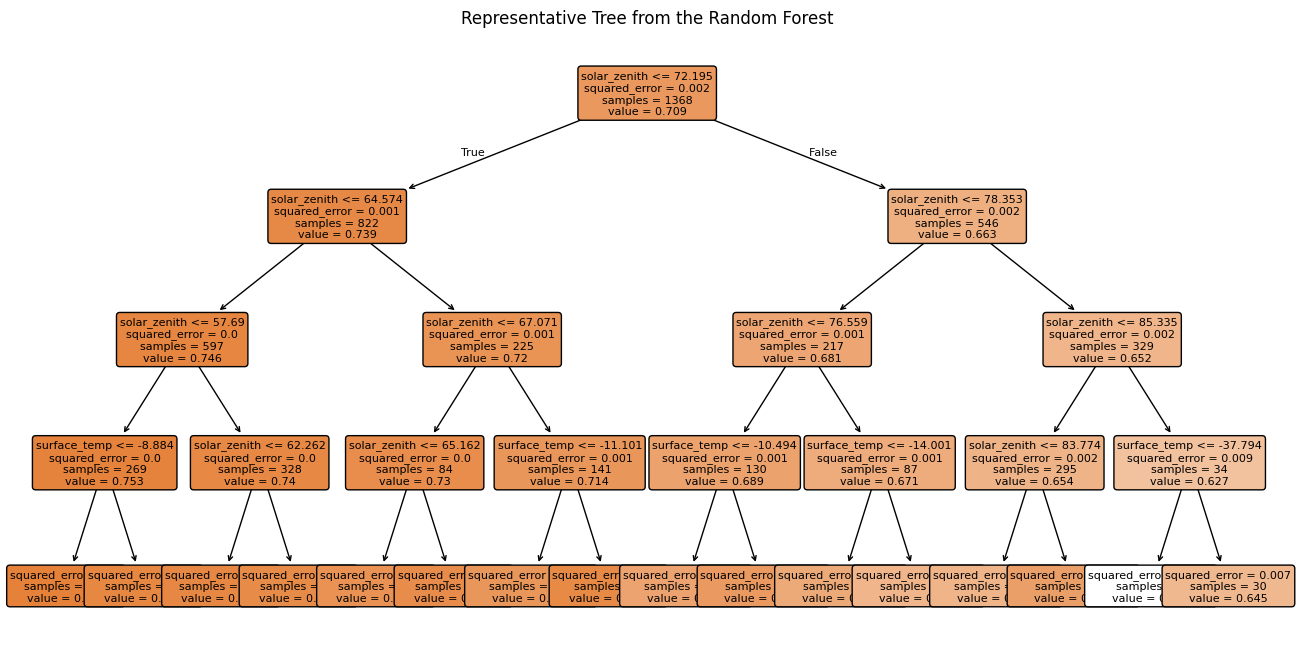

In [12]:
plt.figure(figsize=(16,8))
plot_tree(rf.estimators_[0],feature_names=X.columns,filled=True,rounded=True,fontsize=8)
plt.title("Representative Tree from the Random Forest")
plt.show()

*Random Forest can estimate how much each predictor contributes to the model's decisions. This helps identify which environmental variables have the strongest influence on Antarctic surface albedo predictions.*

In [20]:
imp=pd.DataFrame({
    "Variables": X.columns,
    "Importance": rf.feature_importances_})
imp=imp.sort_values("Importance", ascending=False)
print(imp)

      Variables  Importance
1  solar_zenith    0.977229
0  surface_temp    0.022771


## *Variable Importance Results*

The Random Forest model identified solar zenith angle as the dominant variable, accounting for approximately 97.7% of the total predictive importance. Surface temperature contributed the remaining 2.3%. This result is consistent with the Decision Tree analysis, where solar zenith angle controlled the upper levels of the tree structure and determined the major environmental groupings before temperature was considered.
The consistency across multiple models suggests that changes in solar illumination geometry mainly influence the large-scale albedo variability across the Larsen C Ice Shelf, while temperature acts mainly as a secondary local adjustment factor.

----

## *AdaBoost Regression*

Unlike Random Forest, which averages many independent trees, AdaBoost builds trees sequentially. Each new tree pays greater attention to observations that previous trees predicted poorly.
The Polynomial Regression model in Part 1 struggled with rare low-albedo observations, while the Decision Tree showed that localized rules could better represent these conditions. AdaBoost allows us to test whether focusing on difficult observations can further improve predictive performance across the Larsen C Ice Shelf.

In [19]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
ada=AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=4),n_estimators=100,random_state=726)
ada.fit(X_train, y_train)
pred_ada=ada.predict(X_test)
mse_ada=mean_squared_error(y_test, pred_ada)
r2_ada=r2_score(y_test, pred_ada)
print("AdaBoost MSE :", mse_ada)
print("AdaBoost R^2 :", r2_ada)

AdaBoost MSE : 0.0014283058013360177
AdaBoost R^2 : 0.40773419306870673


## *Interpretation*

The AdaBoost model achieved a Mean Squared Error (MSE) of *0.001428* and an $R^2$ score of *0.40773* on the test dataset.

Compared to both the Decision Tree and Random Forest models, AdaBoost produced a substantially higher prediction error and explained a smaller proportion of the observed variation in surface albedo. Under the selected model configuration, the boosting approach was less effective at capturing the environmental relationships present within the dataset.

An $R^2$ value of approximately *0.4077* indicates that the model explained around 40.77% of the variability in surface albedo, leaving a considerable portion of the observed variation unaccounted for. This performance was noticeably lower than that achieved by the other tree-based methods.

One possible explanation is that the sequential boosting process placed excessive emphasis on a subset of difficult observations, reducing the model's ability to generalize across the broader range of environmental conditions represented in the dataset.

Overall, the AdaBoost results suggest that increasing model complexity does not necessarily improve predictive performance. For this study, both the Decision Tree and Random Forest were better suited to representing the relationship between surface temperature, solar zenith angle, and Antarctic surface albedo.


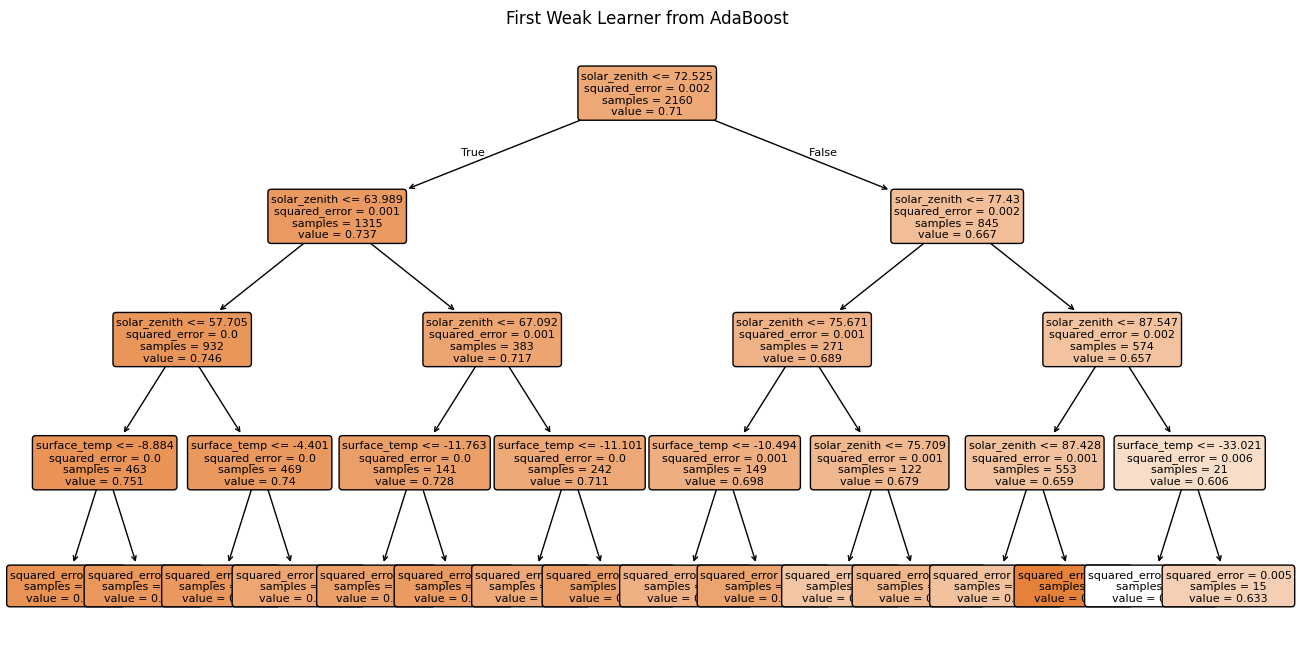

In [13]:
plt.figure(figsize=(16,8))
plot_tree(ada.estimators_[0],feature_names=X.columns,filled=True,rounded=True,fontsize=8)
plt.title("First Weak Learner from AdaBoost")
plt.show()

## *Comparing Model Performance*

To evaluate the effectiveness of each machine learning approach, the test-set performance metrics are summarized below. Lower Mean Squared Error (MSE) values indicate smaller prediction errors, while higher $R^2$ values indicate a greater proportion of explained variability in Antarctic surface albedo.

In [14]:


results=pd.DataFrame({"Model": ["Decision Tree","Random Forest","AdaBoost"],
    "MSE": [mse_tree,mse_rf,mse_ada],
    "RMSE": [np.sqrt(mse_tree),np.sqrt(mse_rf),np.sqrt(mse_ada)],
    "R2": [r2_tree,r2_rf,r2_ada]})
results.sort_values("MSE")



,Model,MSE,RMSE,R2
1,Random Forest,0.000793,0.028162,0.671134
0,Decision Tree,0.000824,0.028708,0.658254
2,AdaBoost,0.001428,0.037793,0.407734


## *Interpretation of Model Comparison*

Among the three models evaluated, the *Random Forest* produced the strongest overall performance, achieving the lowest prediction error (MSE = 0.000793) and the highest $R^2$ score (0.671134). This suggests that combining predictions from multiple shallow decision trees improved the model's ability to capture non-linear relationships between environmental conditions and surface albedo.

The *Decision Tree* achieved very similar results, with only a slight reduction in predictive performance compared to the Random Forest. This indicates that much of the variability in Antarctic surface albedo can be explained through a relatively simple set of environmental decision rules, making the model both effective and easy to interpret.

The *AdaBoost* model produced the weakest performance in this comparison. Although boosting is often effective for improving predictive accuracy, the model explained a smaller proportion of the observed variation in albedo and generated a noticeably higher prediction error than the other approaches under the chosen depth constraint.

Overall, all three models identified meaningful relationships between the environmental variables and surface albedo. However, the Random Forest provided the best predictive performance, while the Decision Tree remained the most interpretable model with only a modest reduction in accuracy. The relatively small difference between the top two models also suggests that the dominant environmental signals within the dataset can be captured effectively using lightweight tree-based approaches.

## *Model Explainability Using SHAP*
Machine learning models can produce accurate predictions, but understanding how those predictions are generated is equally important. SHAP (SHapley Additive exPlanations) provides a way to quantify how each environmental variable contributes to a model's output.

The previous analyses showed that solar zenith angle consistently dominated the predictive process. SHAP allows us to investigate this relationship in detailed way by measuring how individual variables influence albedo predictions across all observations.

This helps connect machine learning results back to physical environmental processes and improves the interpretability of the model.

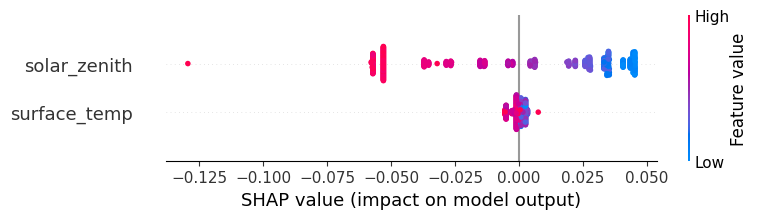

In [22]:
import shap
explainer=shap.TreeExplainer(tree)
shap_values=explainer.shap_values(X_test)
shap.summary_plot(shap_values,X_test,feature_names=X.columns)

## *Interpretation*

The SHAP summary plot ranks variables according to their contribution to model predictions. Consistent with the Decision Tree and Random Forest analyses, solar zenith angle emerged as the dominant predictor of Antarctic surface albedo, while surface temperature played a substantially smaller role.

The wide spread of SHAP values for solar zenith indicates that changes in illumination geometry can strongly influence predicted albedo across the Larsen C Ice Shelf. Lower solar zenith values generally contribute positively to predicted albedo, whereas higher solar zenith values contribute negatively.

One notable feature of the plot is the presence of an extreme negative SHAP value associated with a high solar zenith observation. This isolated point indicates that under certain illumination conditions, solar geometry can put an unusually strong influence on the model's prediction, likely corresponding to rare low-albedo environmental states.

Surface temperature exhibits a much narrower SHAP range and remains tightly clustered around zero. This suggests that its influence is comparatively localized and mainly acts as a secondary adjustment factor rather than a primary driver of reflectance variability.

The SHAP analysis concludes that solar illumination geometry explains most of the observed variation in Antarctic surface albedo during the study period.

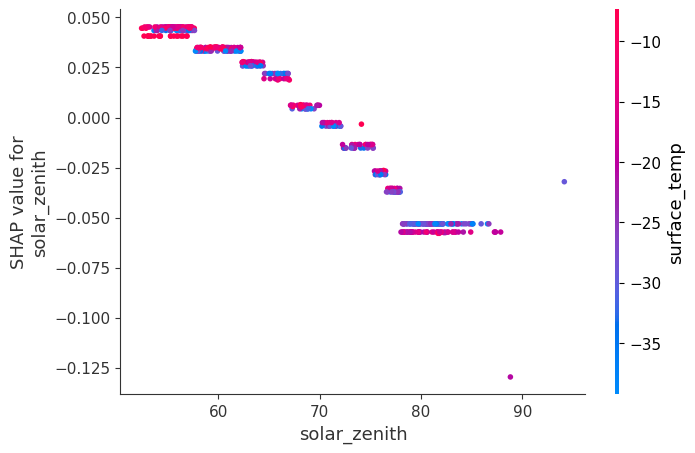

In [23]:
shap.dependence_plot("solar_zenith",shap_values,X_test,feature_names=X.columns)

## *Interpretation*

The SHAP dependence plot illustrates how the influence of solar zenith angle changes across its observed range. As solar zenith increases, the SHAP contribution becomes progressively more negative, indicating a reduction in predicted surface albedo.

Instead of forming a smooth curve, the relationship appears as a staircase pattern. This behavior reflects the structure of tree-based models, which make predictions through a series of threshold-based splits rather than a continuous mathematical equation. Each step represents a decision boundary learned by the model.
The visible intermingling of colder and warmer temperature observations within the same staircase levels suggests that surface temperature contributes local variability across multiple illumination regimes. However, the major shifts between staircase levels remain controlled by solar zenith thresholds, indicating that illumination geometry continues to be the dominant factor driving prediction changes.
A particularly notable feature appears at the highest solar zenith values, where the staircase drops sharply into a strongly negative SHAP region. The isolated outlier observed near a SHAP value of approximately -0.13 is associated with both an extreme solar zenith angle and a relatively warm surface temperature. This combination corresponds to conditions that strongly reduce predicted albedo and is consistent with the lowest-reflectivity states observed within the dataset.

The SHAP results indicate that solar zenith angle performs most of the predictive work when estimating Antarctic surface reflectivity, while surface temperature primarily refines predictions within the broader illumination regimes established by solar geometry.


## *Conclusion*

This two-part study investigated whether machine learning techniques could model Antarctic surface albedo dynamics using a reduced set of satellite-derived environmental indicators extracted over the Larsen C Ice Shelf between 2015 and 2025.

Part 1 established a baseline using a custom Degree-2 Polynomial Regression model optimized through Gradient Descent. The model successfully captured the dominant reflectance behavior of the ice shelf and demonstrated that meaningful environmental relationships could be extracted from a lightweight tabular representation of Earth Observation data. However, diagnostic analysis revealed reduced performance under uncommon low-albedo conditions, indicating limitations associated with a single global regression surface.


Part 2 extended the analysis using Decision Tree, Random Forest, and AdaBoost regression models. Among the models evaluated, the Random Forest achieved the strongest predictive performance, producing the lowest prediction error and highest $R^2$ score. The results indicate that combining multiple shallow decision trees improved the model's ability to capture non-linear environmental relationships while maintaining stable generalization across unseen observations.

The explainability results showed a clear and consistent pattern across the different models. Solar zenith angle was identified as the primary variable influencing surface albedo, while surface temperature mainly helped refine predictions under specific conditions. Similar conclusions were obtained from the Decision Tree, Random Forest, and SHAP analyses.


Overall, this study shows that machine learning can be used to model Antarctic surface albedo using only a small number of environmental variables. The results consistently identified solar zenith angle as the most important factor influencing albedo across the Larsen C Ice Shelf. While there is still scope to improve predictions by including additional variables and higher-resolution data, these findings demonstrate that even relatively simple models can provide useful insights into the environmental processes that drive Antarctic surface reflectivity.

---
---